In [23]:
import numpy as np
import random
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import normalized_mutual_info_score
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from sklearn.utils.class_weight import compute_class_weight
import matminer.featurizers.composition as mm_composition
import matminer.featurizers.structure as mm_structure
from pymatgen.core import Composition
from torch_geometric.utils import subgraph
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Dropout, Sequential, ReLU, MultiheadAttention, LayerNorm, BatchNorm1d
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import GCNConv, GINEConv, global_mean_pool


def filter_cluster_outliers(embeddings, cluster_labels, alpha=1.5):
    filtered_embeddings = []
    filtered_labels = []
    filtered_indices = []

    unique_clusters = np.unique(cluster_labels)

    for cluster_id in unique_clusters:
        idx = np.where(cluster_labels == cluster_id)[0]
        cluster_emb = embeddings[idx]

        if len(cluster_emb) < 2:
            continue

        centroid = np.mean(cluster_emb, axis=0)
        distances = np.linalg.norm(cluster_emb - centroid, axis=1)

        # threshold = mean + α * std
        d_mean = distances.mean()
        d_std = distances.std()
        threshold = d_mean + alpha * d_std

        mask = distances <= threshold

        filtered_embeddings.append(cluster_emb[mask])
        filtered_labels.append(cluster_labels[idx][mask])
        filtered_indices.append(idx[mask])

    filtered_embeddings = np.vstack(filtered_embeddings)
    filtered_labels = np.concatenate(filtered_labels)
    filtered_indices = np.concatenate(filtered_indices)
    return filtered_embeddings, filtered_labels, filtered_indices



def try_multiple_cluster_combinations(Z, all_embeddings, pos_additives_names, args):
    possible_clusters = range(3, args.max_cluster+1)
    best_score = -1
    best_k = None
    best_labels = None
    best_embeddings = None
    best_names = None
    best_Z = None

    for k in possible_clusters:
        cluster_labels = fcluster(Z, t=k, criterion='maxclust')

        # filter the outliers in each cluster
        filtered_embeddings, filtered_labels, filtered_indices = filter_cluster_outliers(all_embeddings, cluster_labels)

        try:
            Z_filt = linkage(filtered_embeddings, method='average', metric='cosine')
            score = silhouette_score(filtered_embeddings, filtered_labels, metric='cosine')
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = filtered_labels
                best_embeddings = filtered_embeddings
                if args.retrain_usl:
                    best_names = None
                else:
                    best_names = np.array(pos_additives_names)[filtered_indices].tolist()
                best_Z = Z_filt
        except Exception as e:
            print(f"k={k} failed: {e}")

    print(f"\n✅ best cluster number: {best_k}, average silhouette score: {best_score:.4f}")

    return best_k, best_labels, best_embeddings, best_names, best_Z



class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return self.mlp(x)
    

class Cluster_GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(Cluster_GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x
    



class GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)
        # self.batch_norm = BatchNorm1d(hidden_channels)


    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        # x = self.batch_norm(x)

        return x


class ProjectionHead_PCL(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

    def forward(self, x):
        return self.mlp(x)

In [6]:
import os
import torch
import argparse
import pandas as pd
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import copy
import time
import umap
import pickle
import numpy as np
import torch.nn.functional as F
import warnings
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from random import sample
import seaborn as sns


warnings.filterwarnings('ignore')

# unsupervised learning configs
parser = argparse.ArgumentParser(description="Train the model")
parser.add_argument('--analysis', type=bool, default=False, help='Wether to print the summary of the dataset')
parser.add_argument('--usl_batch_size', type=int, default=256, help='Batch size for training')
parser.add_argument('--num_classes', type=int, default=2, help='Number of classes')
parser.add_argument('--usl_learning_rate', type=float, default=0.0005, help='Learning rate')
parser.add_argument('--usl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--epoch', type=int, default=500, help='Number of training epochs')
parser.add_argument('--dropout', type=float, default=0.5, help='Value of dropout')
parser.add_argument('--training_types', type=str, default='Unsupervised learning', help='training_types')
parser.add_argument('--models', type=str, default='GINE', help='Training models')
parser.add_argument('--embed_dim', type=int, default=256, help='Embedding dimension of attention')
parser.add_argument('--num_heads', type=int, default=4, help='Number of heads for attention')
parser.add_argument('--desp_dim', type=int, default=217, help='Number of descriptors')
parser.add_argument('--retrain_usl', type=bool, default=False, help='retrain the usl models')
parser.add_argument('--usl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
parser.add_argument('--save_path', type=str, default='checkpoints', help='')


# graph augmentation configs
parser.add_argument('--aug_types', type=str, default='all', help='augmentation types')
parser.add_argument('--shuffle_ratio', type=float, default=0.2, help='shuffle ratio')
parser.add_argument('--node_drop_ratio', type=float, default=0.2, help='node drop ratio')
parser.add_argument('--noise_ratio', type=float, default=0.2, help='noise_ratio')
parser.add_argument('--noise_std', type=float, default=0.1, help='noise_std')
parser.add_argument('--edge_drop_ratio', type=float, default=0.1, help='edge drop ratio')
parser.add_argument('--edge_add_ratio', type=float, default=0.05, help='edge add ratio')
parser.add_argument('--alpha', type=float, default=0.15, help='PPR alpha')
parser.add_argument('--PPR_drop_ratio', type=float, default=0.2, help='PPR_drop_ratio')
parser.add_argument('--PPR_add_ratio', type=float, default=0.2, help='PPR_add_ratio')
parser.add_argument('--K', type=int, default=10, help='PPR K')
parser.add_argument('--random_state', type=int, default=42, help='data split random seed')
parser.add_argument('--test_size', type=float, default=0.2, help='test set size')

# prototypes configs
parser.add_argument('--max_cluster', type=int, default=10, help='max cluster number')
parser.add_argument('--temperature', type=float, default=0.1, help='temperature coefficient for prototypes')
parser.add_argument('--proto_epoch', type=int, default=300, help='Number of training epochs')
parser.add_argument('--r', type=int, default=10000, help='number of randomly select neg prototypes')
parser.add_argument('--proto_training_types', type=str, default='Prototype contrastive learning', help='training_types')
parser.add_argument('--proto_models', type=str, default='GINE', help='model name for PCL')
parser.add_argument('--pcl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--pcl_learning_rate', type=float, default=0.00001, help='Learning rate')
parser.add_argument('--pcl_batch_size', type=int, default=1024, help='Batch size for training')
parser.add_argument('--threshold', type=float, default=0.3, help='threshold')
parser.add_argument('--topk', type=int, default=35, help='top k samples for each prototype')
parser.add_argument('--pcl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
parser.add_argument('--save_proto_drift', type=bool, default=False, help='Whether to save prototype drift information')


# main configs
parser.add_argument('--task', type=str, default='train', help='task types')

args = parser.parse_args([])
device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')

data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
# data preparation
with open(data_path, 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126] # number of positive samples
unlabeled_samples = all_data[126:]

In [24]:
file_path = '/home/hwx/python_project/test/Boron/checkpoints/Unsupervised learning_model_GINE.pth'

print(f"Loading the pretrained model from {file_path}...")

encoder = GINE(num_node_features=positive_samples[0].x.shape[1], num_edge_features=positive_samples[0].edge_attr.shape[1], 
        hidden_channels=args.pcl_hidden_channels,
        num_classes=args.num_classes, dropout=args.dropout, args=args).to(device)
projection = ProjectionHead_PCL(in_dim=args.pcl_hidden_channels).to(device)
encoder.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}/encoder_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
projection.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}/projection_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
proto_centroids = torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}/proto_centroids_{args.proto_models}_epoch_{args.proto_epoch}.pth')

print(f'Model is loaded!')

pos_loader = DataLoader(positive_samples, batch_size=args.pcl_batch_size, shuffle=False)


def get_embeddings(encoder, projection, dataloader, proto_centroids):
    encoder.eval()
    projection.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []

    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            proto_centroids = proto_centroids.to(device)

            query = encoder(data.x, data.edge_index, data.edge_attr, data.batch)
            query = projection(query)
            query = F.normalize(query, dim=-1)
            all_ids.append(data.id.cpu())
            all_embeddings.append(query.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_ids = torch.cat(all_ids, dim=0)

    return all_embeddings, all_ids

emb_pos, pos_ids = get_embeddings(encoder, projection, pos_loader, proto_centroids)
print("All positive embeddings shape:", emb_pos.shape)
print("All positive ids shape:", pos_ids.shape)


# load proto_table_trial_7
proto_df = pd.read_csv(f'/home/hwx/python_project/test/Boron/result_files_origin_backup/proto_table_trial_7.csv')
print(proto_df)

# load PSL proto centroids
proto_centroids = torch.load(f'/home/hwx/python_project/test/Boron/checkpoints_origin_backup/proto_centroids_GINE_epoch_300.pth')



Loading the pretrained model from /home/hwx/python_project/test/Boron/checkpoints/Unsupervised learning_model_GINE.pth...
Model is loaded!
All positive embeddings shape: torch.Size([126, 128])
All positive ids shape: torch.Size([126])
     molecule_id  prototypes molecule_name
0             12           1     ['SOFPB']
1             24           1    ['NHCABT']
2             95           1       ['BDB']
3             66           1     ['BEG-1']
4             83           1    ['DPD-CN']
..           ...         ...           ...
675        40011           7            []
676       117100           7            []
677        26100           7            []
678          100           7       ['PBA']
679        40100           7            []

[680 rows x 3 columns]



Embedding DataFrame preview:
   molecule_id     emb_0     emb_1     emb_2     emb_3     emb_4     emb_5  \
0            0  0.018197  0.015819 -0.001737  0.059906  0.048975  0.132248   
1            1 -0.011756 -0.026119  0.050626 -0.050497 -0.018542 -0.056216   
2            2 -0.015524  0.009710  0.011172  0.067897  0.022025  0.137206   
3            3  0.106704 -0.005322  0.068365  0.037578 -0.085469 -0.079394   
4            4 -0.074492  0.046242  0.022941  0.061489 -0.175567 -0.044424   

      emb_6     emb_7     emb_8  ...   emb_118   emb_119   emb_120   emb_121  \
0 -0.136106  0.003363  0.058337  ...  0.149807 -0.001107  0.035443 -0.149108   
1 -0.062427 -0.084982 -0.023340  ... -0.200659 -0.087361  0.065988  0.138895   
2 -0.102347 -0.014868  0.001246  ...  0.141312  0.022446  0.062420 -0.103989   
3  0.093301  0.093619  0.101625  ...  0.023734  0.069577  0.052389  0.054948   
4  0.015807  0.132901 -0.039092  ...  0.072233  0.039855 -0.115390  0.030948   

    emb_122   emb_12

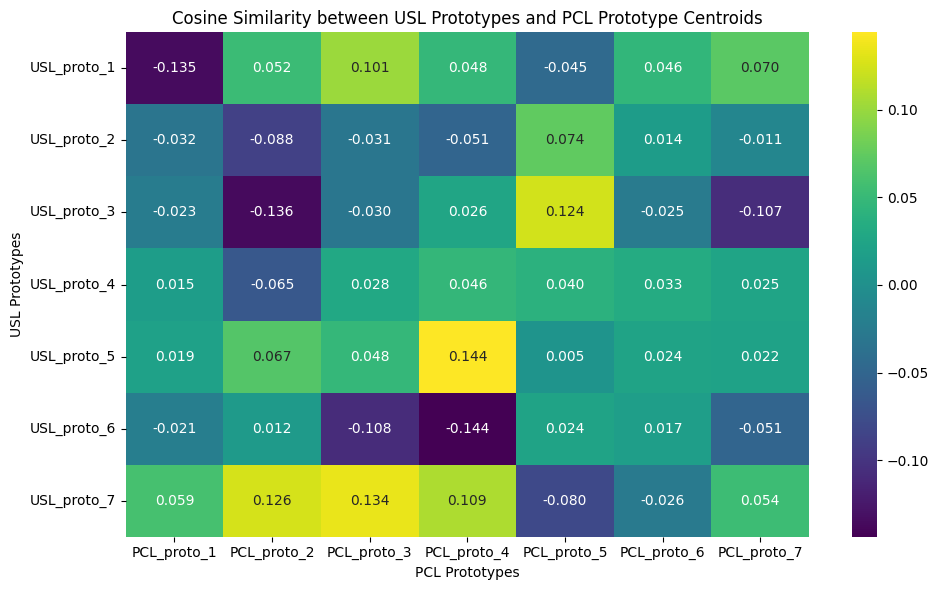

In [25]:
required_cols = ['molecule_id', 'prototypes']
for col in required_cols:
    if col not in proto_df.columns:
        raise ValueError(f"proto_table 缺少必要列: {col}")

# =========================================================
# 4. 提取所有 positive samples 的 PCL embeddings
#    注意：这里不是 top-k，而是每个 positive sample 一次
# =========================================================
pos_loader_all = DataLoader(positive_samples, batch_size=args.pcl_batch_size, shuffle=False)


# =========================================================
# 5. 将 embeddings 转成 DataFrame
# =========================================================
emb_array = emb_pos.numpy()
emb_cols = [f'emb_{i}' for i in range(emb_array.shape[1])]

emb_df = pd.DataFrame({
    'molecule_id': pos_ids.numpy()
})
emb_df[emb_cols] = emb_array

print("\nEmbedding DataFrame preview:")
print(emb_df.head())

# =========================================================
# 6. 与 proto_table 合并
#    这里只会保留 positive_samples 中出现的 molecule_id
# =========================================================
merge_cols = ['molecule_id', 'prototypes']
if 'molecule_name' in proto_df.columns:
    merge_cols.append('molecule_name')

merged_df = emb_df.merge(
    proto_df[merge_cols],
    on='molecule_id',
    how='inner'
)

print("\nMerged DataFrame preview:")
print(merged_df.head())
print("\nMerged positive sample count:", len(merged_df))
print("Unique positive molecule count after merge:", merged_df['molecule_id'].nunique())

# 去重检查：如果一个 molecule_id 出现多次，提醒一下
dup_counts = merged_df['molecule_id'].value_counts()
num_duplicates = (dup_counts > 1).sum()
print("Number of duplicated molecule_id after merge:", num_duplicates)

# =========================================================
# 7. 按 USL prototype 分组，计算每组 positive embeddings 的均值中心
# =========================================================
usl_proto_centers = []
usl_proto_labels = []
usl_proto_counts = []

for usl_label, group in merged_df.groupby('prototypes'):
    group_emb = group[emb_cols].values.astype(np.float32)   # [n_group, D]
    center = group_emb.mean(axis=0)                         # [D]

    # L2 normalize，方便直接做余弦相似度
    center = center / (np.linalg.norm(center) + 1e-12)

    usl_proto_centers.append(center)
    usl_proto_labels.append(usl_label)
    usl_proto_counts.append(len(group))

usl_proto_centers = np.stack(usl_proto_centers, axis=0)   # [N_usl_proto, D]
usl_proto_labels = np.array(usl_proto_labels)
usl_proto_counts = np.array(usl_proto_counts)

print("\nUSL proto centers shape:", usl_proto_centers.shape)
print("USL proto labels:", usl_proto_labels)
print("Num positive samples in each USL proto:", usl_proto_counts)

# =========================================================
# 8. 读取 PCL proto centroids 并标准化
# =========================================================
pcl_proto_centroids = F.normalize(proto_centroids, dim=-1).cpu().numpy()   # [N_pcl_proto, D]

print("\nPCL proto centroids shape:", pcl_proto_centroids.shape)

# 维度检查
if usl_proto_centers.shape[1] != pcl_proto_centroids.shape[1]:
    raise ValueError(
        f"维度不一致：USL中心维度={usl_proto_centers.shape[1]}, "
        f"PCL centroid维度={pcl_proto_centroids.shape[1]}"
    )

# =========================================================
# 9. 计算 USL prototype 与 PCL prototype centroids 的余弦相似度矩阵
# =========================================================
sim_matrix = usl_proto_centers @ pcl_proto_centroids.T   # [N_usl_proto, N_pcl_proto]

sim_df = pd.DataFrame(
    sim_matrix,
    index=[f'USL_proto_{x}' for x in usl_proto_labels],
    columns=[f'PCL_proto_{i+1}' for i in range(sim_matrix.shape[1])]
)

print("\nSimilarity matrix:")
print(sim_df)

# =========================================================
# 10. 计算 mapping 结果
# =========================================================
best_pcl_idx = sim_matrix.argmax(axis=1)
best_pcl_sim = sim_matrix.max(axis=1)

# top-2 margin，判断 mapping 清不清晰
if sim_matrix.shape[1] >= 2:
    sorted_sims = np.sort(sim_matrix, axis=1)[:, ::-1]
    top1_sims = sorted_sims[:, 0]
    top2_sims = sorted_sims[:, 1]
    top2_margin = top1_sims - top2_sims
else:
    top2_margin = np.zeros_like(best_pcl_sim)

mapping_df = pd.DataFrame({
    'USL_proto': usl_proto_labels,
    'Mapped_PCL_proto': best_pcl_idx + 1,   # 从1开始编号，更符合你表里的风格
    'Cosine_similarity': best_pcl_sim,
    'Top2_margin': top2_margin,
    'Num_positive_samples': usl_proto_counts
})

mapping_df = mapping_df.sort_values('USL_proto').reset_index(drop=True)

print("\nUSL -> PCL mapping result:")
print(mapping_df)


# =========================================================
# 12. 画热图
# =========================================================
plt.figure(figsize=(10, 6))
sns.heatmap(sim_df, annot=True, cmap='viridis', fmt='.3f')
plt.title('Cosine Similarity between USL Prototypes and PCL Prototype Centroids')
plt.xlabel('PCL Prototypes')
plt.ylabel('USL Prototypes')
plt.tight_layout()
plt.show()